### Coffee & Coding - Survey Comment Classification : Keyword matching vs TD-IDF vs SetFit

#### The question we are answering today

***"Given a free-text workplace survey comment, can we automatically classify it into a theme?"***

# Plan

| Section | Topic
|---|---|
| 01 | Install relevant libraries
| 02 | The data - what are we working with?
| 03 | Approach 1 - Keyword matching
| 04 | Approach 2 - ML classifier (scikit-learn)
| 05 | Approach 3 - SetFit
| 06 | Comparison

We will need GPU for training model in the later stage. Go to **Runtime** and select **Change runtime Type** and select **T4 GPU**

In [1]:
# Install required libraries
# This may take 1-2 minutes the first time
# Versions are pinned to a combination known to work together.

import os
# Note, we not now allowed to do this in Fabric due to recent python package attack
%pip install -q scikit-learn pandas numpy matplotlib seaborn
%pip install -q "setfit==1.1.0" "transformers==4.44.2" "sentence-transformers==3.0.1" "accelerate==0.34.2" "datasets==2.21.0"

import transformers
needs_restart = transformers.__version__ != "4.44.2"

if needs_restart:
    print("Installed the correct versions, but this Colab session had a different")
    print("version already loaded. Restarting the runtime now to apply it --")
    print("this is expected. When it reconnects, just click 'Run all' again.")
    os.kill(os.getpid(), 9)
else:
    print("All libraries installed and loaded correctly -- no restart needed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires hugging

We will need GPU in the later stage (train model using `SetFit`) so let's check if we change the runtime

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using devide: {device}")

# Check which GPU is attached, it not we will need to change setting
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected, go to Runtime -> Change runtime type -> GPU and you will need to RESTART runtime and re-run from the top")

Using devide: cuda
GPU: Tesla T4


In [3]:
# Import everything we'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn — the ML library
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# SetFit
import transformers
assert transformers.__version__ == "4.44.2", (
    f"transformers is version {transformers.__version__}, expected 4.44.2. "
    "Go to Runtime > Restart runtime, then run all cells again from the top."
)
from setfit import SetFitModel, Trainer, TrainingArguments
from datasets import Dataset

print("All imports successful")


All imports successful


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# The Data
## What datawet are we using?

We are using the Glassdoor Job Reviews dataset from [Kaggle](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews) as inspiration. It contains real workplace comments written by employees about their jobs, things like:


*   "Great work-life balance, very flexible hours"
*   "Management doesn't listen to feedback"
*   "No opportunities to grow or develop skills"

We think the customer survey would be similar, they have different themes, but with free-text responses about how they feel about our service."

### For our session, we have 4 classification themes

We will classify each comment into one of these themes

| Theme | What it covers|Example
|---|---|---|
| `work_life_balance` | Hours, flexibility, workload,stress| "Too many hours, no flexibility"
| `management` | Managers, leadership, communication| "My manager always gives feedback"
| `career_growth` | Training, development, progression | "No promotion opportunities here"
| `culture` | Team, environment, values, inclusion | "Great team atmosphere, very supportive"

We have created synthetic `workplace_survey_comments.csv` data. We used Copilot to generate 400 comments across our 4 themes. Each theme is a 60/40 mix of two styles:



*   Direct comments - say the theme in obvious words. For example, "flexible hours", "my manager", "training opportunities". These are easy to spot, for a computer and for a human
*   Indirect comments - get across the same idea, but without using any of the obvious words. The meaning is more nuanced; you have to read between the lines - the tone rather than spot a keyword. For example, instead of writing "good work-life balance", someome might write "I'm exhausted every single evening". There is no work-life-balance vocabulary in there at all, but the meaning is obvious for human reader.


**Why mix the two together?** Because comments aren't split neatly into "easy" and "hard". Real feedback comes in both flavours, and covers both good and bad experiences either way. If we only tested on the easy, direct comments, keyword matching would look far better than it really is. Mixing in the indirect comments, the ones with no obvious keywords, gives us an better test. It shows us which methods can genuinely understand what someone means, and which ones are just spotting words.













In [4]:
# Load dataset
# Reads straight from the GitHub repo -- no upload needed.
# Falls back to a local file, then a manual upload, if the URL ever fails.

import pandas as pd
import os

CSV_URL = (
    "https://raw.githubusercontent.com/nhsbsa-data-analytics/coffee-and-coding/"
    "survey-comments/2026-07-29%20Classifying%20Survey%20Comments/"
    "workplace_survey_synthetic_comments.csv"
)
CSV_FILENAME = "workplace_survey_comments.csv"

try:
    df = pd.read_csv(CSV_URL)
    print(f"Loaded from GitHub: {CSV_URL}")
except Exception as e:
    print(f"Could not load from URL ({e}), falling back...")
    if os.path.exists(CSV_FILENAME):
        df = pd.read_csv(CSV_FILENAME)
        print(f"Loaded from local file: {CSV_FILENAME}")
    else:
        try:
            from google.colab import files
            print(f"Please select '{CSV_FILENAME}' in the upload dialog...")
            uploaded = files.upload()
            CSV_FILENAME = list(uploaded.keys())[0]
            df = pd.read_csv(CSV_FILENAME)
        except ImportError:
            raise FileNotFoundError(
                f"Could not find {CSV_FILENAME} -- check CSV_URL or upload manually."
            )

print(f"\nDataset shape: {df.shape}")
print(f"\nTheme distribution:")
print(df["theme"].value_counts())
print(f"\nDifficulty split (per theme: 60 direct, 40 indirect):")
print(df["difficulty"].value_counts())
print(f"\nSample comments:")
df.sample(8, random_state=42)[["theme", "difficulty", "comment"]]

Loaded from GitHub: https://raw.githubusercontent.com/nhsbsa-data-analytics/coffee-and-coding/survey-comments/2026-07-29%20Classifying%20Survey%20Comments/workplace_survey_synthetic_comments.csv

Dataset shape: (400, 3)

Theme distribution:
theme
career_growth        100
work_life_balance    100
culture              100
management           100
Name: count, dtype: int64

Difficulty split (per theme: 60 direct, 40 indirect):
difficulty
direct      240
indirect    160
Name: count, dtype: int64

Sample comments:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,theme,difficulty,comment
209,management,indirect,Whoever's in charge treats mistakes as somethi...
280,work_life_balance,direct,Good balance between work demands and personal...
33,work_life_balance,direct,Working from home just means working longer hours
210,career_growth,direct,Internal vacancies are filled externally which...
93,career_growth,direct,No training opportunities whatsoever in this role
84,career_growth,indirect,I had to leave to actually move forward
329,management,indirect,Whoever I report to actually listens when I ra...
94,management,indirect,I know exactly what's expected of me each week


##### Visualise the class distribution

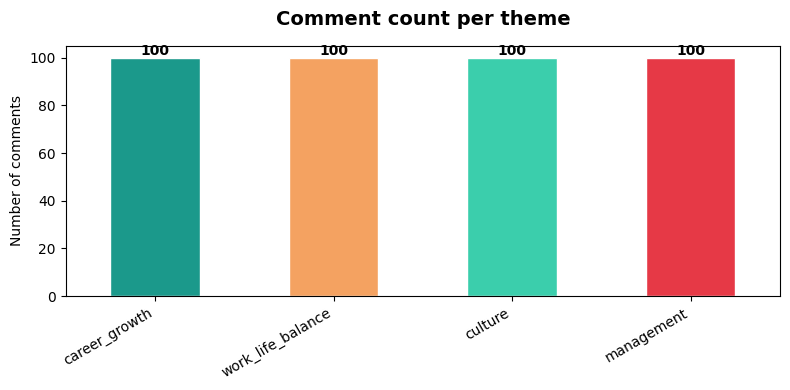

✅ We have a balanced dataset — 100 comments per theme


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Visualise the class distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1B998B', '#F4A261', '#3BCEAC', '#E63946']
df['theme'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Comment count per theme', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('Number of comments')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()
print("Balanced dataset — 100 comments per theme")


#### Note on class balance

This dataset is perfectly balanced. (Exactly 100 comments per theme) well, because we built it that way on purpose, to keep our comparision fair and easy to follow.

Real data is almost never this tidy! In practice, you will most definitely see class imbalance. Some themes come up far more often than others. That matters because:

*   A model can get a misleadingly high accuracy just by favouring the monority theme
*   Minority themes are the ones most likely to get missed or misclasified
*   Accuracy alone can hide this - metrics like **precision**, **recall**, and **F1 per class**

So, when we take these methods to real data, check theme distribution first, and read the per-class scores.

